In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import sys, platform, os
sys.path.append('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/interface/')
os.environ['OMP_NUM_THREADS'] = '8'
import matplotlib
import math
from matplotlib import pyplot as plt
import numpy as np
import euclidemu2
import scipy
import cosmolike_roman_real_interface as ci
from getdist import IniFile
from scipy.interpolate import interp1d
import itertools
import iminuit
import functools
print(sys.version)
print(os.getcwd())

# GENERAL PLOT OPTIONS
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
matplotlib.rcParams['xtick.bottom'] = True
matplotlib.rcParams['xtick.top'] = False
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['axes.edgecolor'] = 'black'
matplotlib.rcParams['axes.linewidth'] = '1.0'
matplotlib.rcParams['axes.labelsize'] = 'medium'
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.linewidth'] = '0.0'
matplotlib.rcParams['grid.alpha'] = '0.18'
matplotlib.rcParams['grid.color'] = 'lightgray'
matplotlib.rcParams['legend.labelspacing'] = 0.77
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.format'] = 'pdf'
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# BE CAREFUL: you need texlive-latex-base texlive-latex-extra texlive-fonts-recommended dvipng ghostscript cm-super
matplotlib.rcParams['text.usetex'] = False
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------

# Jupyter Notebook Display options
import IPython
IPython.display.display(IPython.display.HTML("<style>:root { --jp-notebook-max-width: 85% !important; }</style>"))
IPython.display.display(IPython.display.HTML("<style>div.output_scroll { height: 54em; }</style>"))

# IMPORT CAMB
sys.path.insert(0, '/project/chihway/junzhou/cocoa_approx/Cocoa/external_modules/code/CAMB/build/lib.linux-x86_64-cpython-310')
if "camb" in sys.modules:
    del sys.modules["camb"]
import camb
from camb import model
print('Using CAMB %s installed at %s'%(camb.__version__,os.path.dirname(camb.__file__)))
# IMPOER EE2
sys.path.insert(0, '/project/chihway/junzhou/cocoa_approx/Cocoa/external_modules/code/euclidemu2/build/lib.linux-x86_64-cpython-310')
if "euclidemu2" in sys.modules:
    del sys.modules["euclidemu2"]
import euclidemu2


Classy could not be found in your system.
Here are some suggestions:

	 -Download the Class from class-code.net and install it
	  together with its wrapper classy (type 'make' instead of
	  'make class'
	 -If you know that Class is installed on your system
	  and yet classy could not be installed, try re-compiling
	  Class with just ''make'' instead of ''make class''
NOTICE: Even without classy you can still use EuclidEmulator2
        to emulate boost factors. You won't be able to compute
        full power spectra, though.
3.10.17 | packaged by conda-forge | (main, Apr 10 2025, 22:19:12) [GCC 13.3.0]
/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real


Using CAMB 1.5.9 installed at /project/chihway/junzhou/cocoa_approx/Cocoa/external_modules/code/CAMB/build/lib.linux-x86_64-cpython-310/camb

Classy could not be found in your system.
Here are some suggestions:

	 -Download the Class from class-code.net and install it
	  together with its wrapper classy (type 'make' instead of
	  'make class'
	 -If you know that Class is installed on your system
	  and yet classy could not be installed, try re-compiling
	  Class with just ''make'' instead of ''make class''
NOTICE: Even without classy you can still use EuclidEmulator2
        to emulate boost factors. You won't be able to compute
        full power spectra, though.


In [2]:
CAMBAccuracyBoost = 1.0
non_linear_emul = 1
CLprobe="3x2pt"

path= "./data/"
data_file="roman_ones.dataset"

IA_model = 0
IA_redshift_evolution = 3

ntheta = 20
theta_min_arcmin = 1.0 
theta_max_arcmin = 500.0

As_1e9= 2.1
ns= 0.96605
H0= 67.32
omegab= 0.0495
omegam= 0.316
mnu= 0.06

Roman_DZ_S1= 0.0
Roman_DZ_S2= 0.0
Roman_DZ_S3= 0.0
Roman_DZ_S4= 0.0
Roman_DZ_S5= 0.0
Roman_DZ_S6= 0.0
Roman_DZ_S7= 0.0
Roman_DZ_S8= 0.0


Roman_DZ_L1= 0.0
Roman_DZ_L2= 0.0
Roman_DZ_L3= 0.0
Roman_DZ_L4= 0.0
Roman_DZ_L5= 0.0
Roman_DZ_L6= 0.0
Roman_DZ_L7= 0.0
Roman_DZ_L8= 0.0
Roman_DZ_L9= 0.0
Roman_DZ_L10= 0.0

Roman_M1= 0.0
Roman_M2= 0.0
Roman_M3= 0.0
Roman_M4= 0.0
Roman_M5= 0.0
Roman_M6= 0.0
Roman_M7= 0.0
Roman_M8= 0.0


Roman_A1_1= 0.5
Roman_A1_2= 0.0

Roman_B1_1= 1.09
Roman_B1_2= 1.15
Roman_B1_3= 1.21
Roman_B1_4= 1.27
Roman_B1_5= 1.33
Roman_B1_6= 1.40
Roman_B1_7= 1.46
Roman_B1_8= 1.53
Roman_B1_9= 1.60
Roman_B1_10= 1.67

w0pwa= -1.0
w= -1.0

In [3]:
def get_camb_cosmology(omegam = omegam, 
                       omegab = omegab, 
                       H0 = H0, 
                       ns = ns, 
                       As_1e9 = As_1e9, 
                       w = w, 
                       w0pwa = w0pwa, 
                       AccuracyBoost=1.0, 
                       kmax=5.0, 
                       k_per_logint=10, 
                       CAMBAccuracyBoost=1.0,
                       non_linear_emul=non_linear_emul,
                       lens_potential_accuracy=1.0,
                       halofit_version='mead2020'):

    As = lambda As_1e9: 1e-9 * As_1e9
    wa = lambda w0pwa, w: w0pwa - w
    omegabh2 = lambda omegab, H0: omegab*(H0/100)**2
    omegach2 = lambda omegam, omegab, mnu, H0: (omegam-omegab)*(H0/100)**2-(mnu*(3.046/3)**0.75)/94.0708
    omegamh2 = lambda omegam, H0: omegam*(H0/100)**2

    CAMBAccuracyBoost = CAMBAccuracyBoost*(1.0 + (AccuracyBoost-1.0)/3.0)
    lens_potential_accuracy = lens_potential_accuracy*CAMBAccuracyBoost
    kmax = kmax*(1.0 + 3*(CAMBAccuracyBoost-1))
    k_per_logint = int(k_per_logint) + int(3*(CAMBAccuracyBoost-1))
    extrap_kmax=2.5e2*CAMBAccuracyBoost
    
    tmp=1250
    z_interp_1D = np.concatenate((np.linspace(0.0,3.0,max(100,int(0.80*tmp))),
                                  np.linspace(3.0,50.1*20,max(100*20,int(0.40*tmp*20)))),axis=0)
    len_z_interp_1D = len(z_interp_1D)
    
    tmp=256
    z_interp_2D = np.concatenate((np.linspace(0,3.0,max(50,int(0.75*tmp))), 
                                  np.linspace(3.01,50.1*20,max(30,int(0.25*tmp)))),axis=0)
    len_z_interp_2D = len(z_interp_2D)
    
    tmp=1500
    log10k_interp_2D = np.linspace(-4.99,2.0,tmp)
    len_log10k_interp_2D = len(log10k_interp_2D)
    
    pars = camb.set_params(H0=H0, 
                           ombh2=omegabh2(omegab, H0), 
                           omch2=omegach2(omegam, omegab, mnu, H0), 
                           mnu=mnu, 
                           omk=0, 
                           tau=0.06,  
                           As=As(As_1e9), 
                           ns=ns, 
                           halofit_version=halofit_version, 
                           lmax=10,
                           AccuracyBoost=CAMBAccuracyBoost,
                           lens_potential_accuracy=lens_potential_accuracy,
                           num_massive_neutrinos=1,
                           nnu=3.046,
                           accurate_massive_neutrino_transfers=False,
                           k_per_logint=k_per_logint,
                           kmax = kmax);
    pars.set_dark_energy(w=w, wa=wa(w0pwa, w), dark_energy_model='ppf');    
    pars.NonLinear = model.NonLinear_both
    pars.set_matter_power(redshifts=z_interp_2D, kmax=kmax, silent=True);
    
    results = camb.get_results(pars)
    
    PKL  = results.get_matter_power_interpolator(var1="delta_tot", 
                                                 var2="delta_tot", 
                                                 nonlinear=False, 
                                                 extrap_kmax=extrap_kmax, 
                                                 hubble_units = False, 
                                                 k_hunit = False);
    PKNL = results.get_matter_power_interpolator(var1="delta_tot", 
                                                 var2="delta_tot",  
                                                 nonlinear=True, 
                                                 extrap_kmax=extrap_kmax, 
                                                 hubble_units=False, 
                                                 k_hunit=False);
    
    lnPL = np.log(PKL.P(z_interp_2D,np.power(10.0, log10k_interp_2D)).flatten(order='F')) + np.log((H0/100.0)**3) 
    
    if non_linear_emul == 1:
        params = { 'Omm'  : omegam, 
                   'As'   : As(As_1e9), 
                   'Omb'  : omegab,
                   'ns'   : ns, 
                   'h'    : H0/100., 
                   'mnu'  : mnu,  
                   'w'    : w, 
                   'wa'   : wa(w0pwa, w)
                 }
        kbt, tmp_bt = euclidemu2.get_boost(params,z_interp_2D[z_interp_2D < 10.0],10**np.linspace(-2.0589,0.973,len_log10k_interp_2D))
        bt = np.array(tmp_bt, dtype='float64')  
        tmp = interp1d(np.log10(kbt), 
                        np.log(bt), 
                        axis=1,
                        kind='linear', 
                        fill_value='extrapolate', 
                        assume_sorted=True)(log10k_interp_2D-np.log10(H0/100.)) #h/Mpc
        tmp[:,10**(log10k_interp_2D-np.log10(H0/100)) < 8.73e-3] = 0.0
        lnbt = np.zeros((len_z_interp_2D, len_log10k_interp_2D))
        lnbt[z_interp_2D < 10.0, :] = tmp
        # Use Halofit first that works on all redshifts
        lnPNL = np.log(PKNL.P(z_interp_2D, np.power(10.0, log10k_interp_2D)).flatten(order='F')) + np.log((H0/100.0)**3) 
        # on z < 10.0, replace it with EE2
        lnPNL = np.where((z_interp_2D<10)[:,None], lnPL.reshape(len_z_interp_2D, len_log10k_interp_2D, order='F') + lnbt, 
                                                   lnPNL.reshape(len_z_interp_2D, len_log10k_interp_2D, order='F')).ravel(order='F')
    elif non_linear_emul == 2:
        lnPNL = np.log(PKNL.P(z_interp_2D, np.power(10.0, log10k_interp_2D)).flatten(order='F')) + np.log((H0/100.0)**3)  
    log10k_interp_2D = log10k_interp_2D - np.log10(H0/100.)
   
    G_growth = np.sqrt(PKL.P(z_interp_2D, 0.0005)/PKL.P(0, 0.0005))*(1 + z_interp_2D)
    G_growth = G_growth/G_growth[len(G_growth)-1]
    
    chi = results.comoving_radial_distance(z_interp_1D) * (H0/100.)
    
    return (log10k_interp_2D, z_interp_2D, lnPL, lnPNL, G_growth, z_interp_1D, chi)

    
def gamma_t(ntheta = ntheta, 
            theta_min_arcmin = theta_min_arcmin, 
            theta_max_arcmin = theta_max_arcmin,
            omegam = omegam, 
            omegab = omegab, 
            H0 = H0, 
            ns = ns, 
            As_1e9 = As_1e9, 
            w = w, 
            w0pwa = w0pwa,
            A1  = [Roman_A1_1, Roman_A1_2, 0, 0, 0, 0, 0, 0], 
            A2  = [0, 0, 0, 0, 0, 0, 0, 0],
            BTA = [0, 0, 0, 0, 0, 0, 0, 0],
            shear_photoz_bias = [Roman_DZ_S1, Roman_DZ_S2, Roman_DZ_S3, Roman_DZ_S4, Roman_DZ_S5, Roman_DZ_S6, Roman_DZ_S7, Roman_DZ_S8],
            M = [Roman_M1, Roman_M2, Roman_M3, Roman_M4, Roman_M5, Roman_M6, Roman_M7, Roman_M8],
            lens_photoz_bias = [Roman_DZ_L1, Roman_DZ_L2, Roman_DZ_L3, Roman_DZ_L4, Roman_DZ_L5, Roman_DZ_L6, Roman_DZ_L7, Roman_DZ_L8, Roman_DZ_L9, Roman_DZ_L10],
            galaxy_bias_b1 = [Roman_B1_1, Roman_B1_2, Roman_B1_3, Roman_B1_4, Roman_B1_5, Roman_B1_6, Roman_B1_7, Roman_B1_8, Roman_B1_9, Roman_B1_10],
            galaxy_bias_b2 = [0,0,0,0,0, 0,0,0,0,0],
            galaxy_bias_bmag = [0,0,0,0,0, 0,0,0,0,0],
            PM = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            baryon_sims = None,
            AccuracyBoost = 1.0, 
            kmax=5.0, 
            k_per_logint=10,
            CAMBAccuracyBoost=1.0,
            CLAccuracyBoost = 1.0, 
            CLIntegrationAccuracy = 0,
            non_linear_emul=non_linear_emul):
        
    (log10k_interp_2D, z_interp_2D, lnPL, lnPNL, G_growth, z_interp_1D, chi) = get_camb_cosmology(omegam=omegam, 
        omegab=omegab, H0=H0, ns=ns, As_1e9=As_1e9, w=w, w0pwa=w0pwa, AccuracyBoost=AccuracyBoost, kmax=kmax,
        k_per_logint=k_per_logint, CAMBAccuracyBoost=CAMBAccuracyBoost,non_linear_emul=non_linear_emul)

    CLAccuracyBoost = CLAccuracyBoost * AccuracyBoost
    CLIntegrationAccuracy = max(0, CLIntegrationAccuracy + 3*(CLAccuracyBoost-1.0))
    ci.init_ntable_lmax(int(50000+10000*CLAccuracyBoost))
    ci.init_accuracy_boost(CLAccuracyBoost, int(CLIntegrationAccuracy))
    ci.init_binning(int(ntheta), theta_min_arcmin, theta_max_arcmin)
    ci.init_bias(bias_model=[0,0,0,1,0])
    
    ci.set_cosmology(omegam = omegam, 
                     H0 = H0, 
                     log10k_2D = log10k_interp_2D, 
                     z_2D = z_interp_2D, 
                     lnP_linear = lnPL,
                     lnP_nonlinear = lnPNL,
                     G = G_growth,
                     z_1D = z_interp_1D,
                     chi = chi)
    
    ci.set_nuisance_shear_calib(M = M)
    ci.set_nuisance_shear_photoz(bias = shear_photoz_bias)
    ci.set_nuisance_clustering_photoz(bias = lens_photoz_bias)
    ci.set_nuisance_bias(B1 = galaxy_bias_b1,
                         B2 = galaxy_bias_b2,
                         B_MAG = galaxy_bias_bmag)
    ci.set_nuisance_ia(A1 = A1, A2 = A2, B_TA = BTA)
    ci.set_point_mass(PMV=PM) 

    if baryon_sims is None:
        ci.reset_bary_struct()
    else:
        ci.init_baryons_contamination(sim = baryon_sims)
    
    return (ci.get_binning_real_space(), ci.w_gammat_tomo())
def w_theta(ntheta = ntheta, 
            theta_min_arcmin = theta_min_arcmin, 
            theta_max_arcmin = theta_max_arcmin,
            omegam = omegam, 
            omegab = omegab, 
            H0 = H0, 
            ns = ns, 
            As_1e9 = As_1e9, 
            w = w, 
            w0pwa = w0pwa,
            lens_photoz_bias = [Roman_DZ_L1, Roman_DZ_L2, Roman_DZ_L3, Roman_DZ_L4, Roman_DZ_L5, Roman_DZ_L6, Roman_DZ_L7, Roman_DZ_L8, Roman_DZ_L9, Roman_DZ_L10],
            galaxy_bias_b1 = [Roman_B1_1, Roman_B1_2, Roman_B1_3, Roman_B1_4, Roman_B1_5, Roman_B1_6, Roman_B1_7, Roman_B1_8, Roman_B1_9, Roman_B1_10],
            galaxy_bias_b2 = [0,0,0,0,0, 0,0,0,0,0],
            galaxy_bias_bmag = [0,0,0,0,0, 0,0,0,0,0],
            baryon_sims = None,
            AccuracyBoost = 1.0, 
            kmax=5.0, 
            k_per_logint=10, 
            CAMBAccuracyBoost=1.0,
            CLAccuracyBoost=1.0, 
            CLIntegrationAccuracy = 0,
            non_linear_emul=non_linear_emul):

    (log10k_interp_2D, z_interp_2D, lnPL, lnPNL, G_growth, z_interp_1D, chi) = get_camb_cosmology(omegam=omegam, 
        omegab=omegab, H0=H0, ns=ns, As_1e9=As_1e9, w=w, w0pwa=w0pwa, AccuracyBoost=AccuracyBoost, kmax=kmax,
        k_per_logint=k_per_logint, CAMBAccuracyBoost=CAMBAccuracyBoost,non_linear_emul=non_linear_emul)

    CLAccuracyBoost = CLAccuracyBoost * AccuracyBoost
    CLIntegrationAccuracy = max(0, CLIntegrationAccuracy + 3*(AccuracyBoost-1.0))
    ci.init_ntable_lmax(int(50000+10000*CLAccuracyBoost))
    ci.init_accuracy_boost(CLAccuracyBoost, int(CLIntegrationAccuracy))
    ci.init_binning(int(ntheta), theta_min_arcmin, theta_max_arcmin)
    ci.init_bias(bias_model=[0,0,0,1,0])
    
    ci.set_cosmology(omegam = omegam, 
                     H0 = H0, 
                     log10k_2D = log10k_interp_2D, 
                     z_2D = z_interp_2D, 
                     lnP_linear = lnPL,
                     lnP_nonlinear = lnPNL,
                     G = G_growth,
                     z_1D = z_interp_1D,
                     chi = chi)
    
    ci.set_nuisance_clustering_photoz(bias = lens_photoz_bias)
    ci.set_nuisance_bias(B1 = galaxy_bias_b1,
                         B2 = galaxy_bias_b2,
                         B_MAG = galaxy_bias_bmag)

    if baryon_sims is None:
        ci.reset_bary_struct()
    else:
        ci.init_baryons_contamination(sim = baryon_sims)

    result = (ci.get_binning_real_space(), ci.w_gg_tomo())  
    return result
def xi(ntheta = ntheta, 
       theta_min_arcmin = theta_min_arcmin, 
       theta_max_arcmin = theta_max_arcmin, 
       omegam = omegam, 
       omegab = omegab, 
       H0 = H0, 
       ns = ns, 
       As_1e9 = As_1e9, 
       w = w, 
       w0pwa = w0pwa,
       A1  = [Roman_A1_1, Roman_A1_2, 0, 0, 0, 0, 0, 0], 
       A2  = [0, 0, 0, 0, 0, 0, 0, 0],
       BTA = [0, 0, 0, 0, 0, 0, 0, 0],
       shear_photoz_bias = [Roman_DZ_S1, Roman_DZ_S2, Roman_DZ_S3, Roman_DZ_S4, Roman_DZ_S5, Roman_DZ_S6, Roman_DZ_S7, Roman_DZ_S8],
       M = [Roman_M1, Roman_M2, Roman_M3, Roman_M4, Roman_M5, Roman_M6, Roman_M7, Roman_M8],
       baryon_sims = None,
       AccuracyBoost=1.0, 
       kmax=5.0, 
       k_per_logint=10, 
       CAMBAccuracyBoost=1.0,
       CLAccuracyBoost=1.0, 
       CLIntegrationAccuracy=0,
       non_linear_emul=non_linear_emul):

    (log10k_interp_2D, z_interp_2D, lnPL, lnPNL, G_growth, z_interp_1D, chi) = get_camb_cosmology(omegam=omegam, 
                                                                                                  omegab=omegab, 
                                                                                                  H0=H0, 
                                                                                                  ns=ns, 
                                                                                                  As_1e9=As_1e9, 
                                                                                                  w=w, 
                                                                                                  w0pwa=w0pwa,
                                                                                                  AccuracyBoost=AccuracyBoost,
                                                                                                  kmax=kmax,
                                                                                                  k_per_logint=k_per_logint,
                                                                                                  CAMBAccuracyBoost=CAMBAccuracyBoost,
                                                                                                  non_linear_emul=non_linear_emul)
    CLAccuracyBoost = CLAccuracyBoost * AccuracyBoost
    CLIntegrationAccuracy = max(0, CLIntegrationAccuracy + abs(3*(CLAccuracyBoost-1.0)))
    ci.init_ntable_lmax(int(50000+10000*CLAccuracyBoost))
    ci.init_accuracy_boost(CLAccuracyBoost, int(CLIntegrationAccuracy))
    
    ci.init_binning(int(ntheta), theta_min_arcmin, theta_max_arcmin)
    ci.set_cosmology(omegam = omegam, 
                     H0 = H0, 
                     log10k_2D = log10k_interp_2D, 
                     z_2D = z_interp_2D, 
                     lnP_linear = lnPL,
                     lnP_nonlinear = lnPNL,
                     G = G_growth,
                     z_1D = z_interp_1D,
                     chi = chi)
    ci.set_nuisance_shear_calib(M = M)
    ci.set_nuisance_shear_photoz(bias = shear_photoz_bias)
    ci.set_nuisance_ia(A1 = A1, A2 = A2, B_TA = BTA)

    if baryon_sims is None:
        ci.reset_bary_struct()
    else:
        ci.init_baryons_contamination(sim = baryon_sims)
        
    (xip, xim) = ci.xi_pm_tomo()    
    return (ci.get_binning_real_space(), xip, xim)

In [4]:
adopt_limber_gg = 0
adopt_limber_gs = 1
adopt_RSD_gg = 1
adopt_RSD_gs = 1
NCell_interpolation = 300
Na_interpolation = 225

# Init Cosmolike
ini = IniFile(os.path.normpath(os.path.join(path, data_file)))
lens_file = ini.relativeFileName('nz_lens_file')
source_file = ini.relativeFileName('nz_source_file')
lens_ntomo = ini.int("lens_ntomo")
source_ntomo = ini.int("source_ntomo")
ci.initial_setup(
      adopt_limber_gg,
    adopt_limber_gs,
    adopt_RSD_gg,
    adopt_RSD_gs,
    NCell_interpolation,
    Na_interpolation,)
ci.init_accuracy_boost(1.0, int(1))
ci.init_cosmo_runmode(is_linear = False)
ci.init_redshift_distributions_from_files(
      lens_multihisto_file=lens_file,
      lens_ntomo=int(lens_ntomo), 
      source_multihisto_file=source_file,
      source_ntomo=int(source_ntomo))
ci.init_IA(ia_model = int(IA_model), ia_redshift_evolution = int(IA_redshift_evolution))


In [36]:
nlens = 10
nsrcs = 8
ndv = int(nsrcs*(nsrcs+1) + nlens*nsrcs + nlens)*ntheta

acamb = 20
na = 5000
ncl = 5000
cambs = np.concatenate((np.linspace(0.5, 1.5, 20), np.array([3])))

dvs = []

for idx,ca in enumerate(cambs):
    print(f'loop {idx}/{len(cambs)-1} start.')
    ci.initial_setup(
      adopt_limber_gg,
      adopt_limber_gs,
      adopt_RSD_gg,
      adopt_RSD_gs,
      ncl,
      na,)
    ci.init_accuracy_boost(1.0, int(1))
    ci.init_cosmo_runmode(is_linear = False)
    ci.init_redshift_distributions_from_files(
        lens_multihisto_file=lens_file,
        lens_ntomo=int(lens_ntomo), 
        source_multihisto_file=source_file,
        source_ntomo=int(source_ntomo))
    ci.init_IA(ia_model = int(IA_model), ia_redshift_evolution = int(IA_redshift_evolution))
    
    ts, wtheta = w_theta(CAMBAccuracyBoost=ca)
    ts, gammat = gamma_t(CAMBAccuracyBoost=ca)
    ts, xip, xim = xi(CAMBAccuracyBoost=ca)
    
    xips = []
    xims = []
    wthetas = []
    for i in range(nsrcs):
      for j in range(i,nsrcs):
        xips.append(xip[:,i,j])
        xims.append(xim[:,i,j])
    for i in range(nlens):
      wthetas.append(wtheta[:,i,i])
    xips = np.array(xips)
    xims = np.array(xims)
    wthetas = np.array(wthetas)
    
    dv = np.concatenate((
    xips.reshape(-1),
    xims.reshape(-1),
    gammat.reshape(20, -1).transpose((1,0)).reshape(-1),
    wthetas.reshape(-1)))
    dvs.append(dv)
    
import scipy

cov_raw = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/data/cov_roman')
cov = np.zeros((ndv,ndv))
for idx in range(len(cov_raw)):
    ii = int(cov_raw[idx, 0])
    jj = int(cov_raw[idx, 1])
    element = cov_raw[idx, 8] + cov_raw[idx, 9]
    cov[ii,jj] = element
    cov[jj,ii] = element
    
mask = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/data/roman_Y3.mask')[:,1].astype(bool)
invcov = scipy.linalg.inv(cov[mask,:][:,mask])

loop 0/20 start.
/project/chihway/junzhou/cocoa_approx/Cocoa/.local/lib/python3.10/site-packages/euclidemu2/ee2_bindata.dat
loop 1/20 start.
loop 2/20 start.
loop 3/20 start.
loop 4/20 start.
loop 5/20 start.
loop 6/20 start.
loop 7/20 start.
loop 8/20 start.
loop 9/20 start.
loop 10/20 start.
loop 11/20 start.
loop 12/20 start.
loop 13/20 start.
loop 14/20 start.
loop 15/20 start.
loop 16/20 start.
loop 17/20 start.
loop 18/20 start.
loop 19/20 start.
loop 20/20 start.


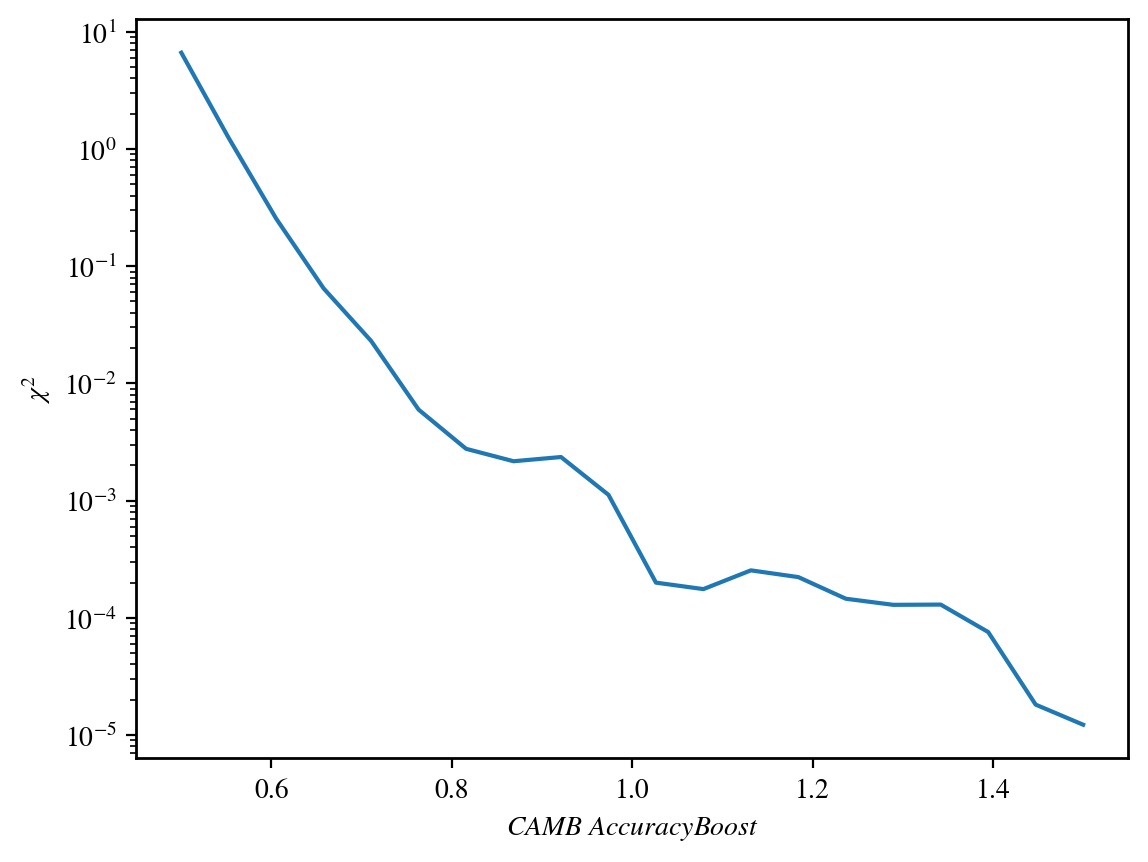

In [37]:
chi2s = []
for i in range(len(cambs)-1):
    delta = (dvs[i]-dvs[-1])[mask]
    chi2 = delta@invcov@delta
    chi2s.append(chi2)


plt.plot(cambs[:-1], chi2s, label='Roman')
plt.yscale('log')
plt.xlabel(r'$CAMB\ AccuracyBoost$')
plt.ylabel(r'$\chi^2$')

out = np.zeros((len(chi2s),2))
out[:, 0] = cambs[:-1]
out[:, 1] = chi2s
np.savetxt('./chi2s_CAMBAB.txt', out)

loop 0/20 start.
loop 1/20 start.
loop 2/20 start.
loop 3/20 start.
loop 4/20 start.
loop 5/20 start.
loop 6/20 start.
loop 7/20 start.
loop 8/20 start.
loop 9/20 start.
loop 10/20 start.
loop 11/20 start.
loop 12/20 start.
loop 13/20 start.
loop 14/20 start.
loop 15/20 start.
loop 16/20 start.
loop 17/20 start.
loop 18/20 start.
loop 19/20 start.
loop 20/20 start.


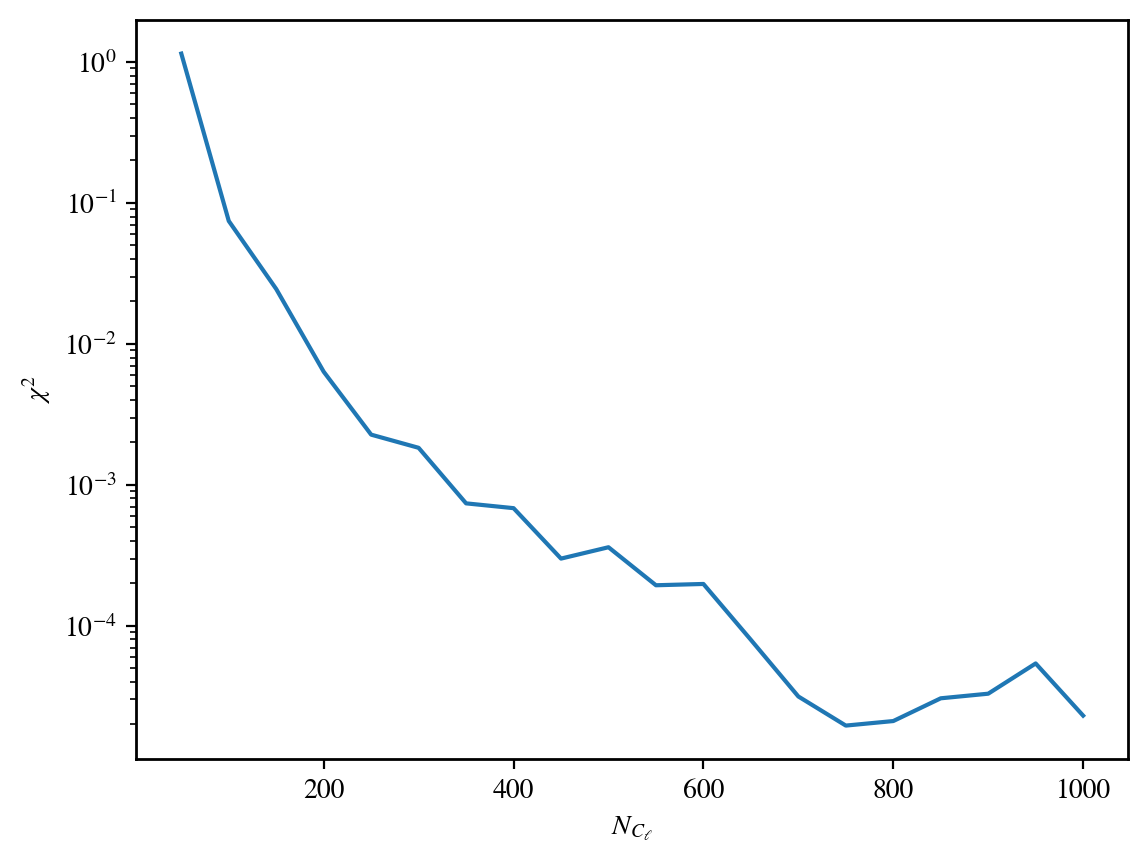

In [38]:
nlens = 10
nsrcs = 8
ndv = int(nsrcs*(nsrcs+1) + nlens*nsrcs + nlens)*ntheta

acamb = 20
na = 5000
ncls = np.concatenate((np.linspace(50, 1000, 20),np.array([5000])))
dvs = []
for idx,ncl in enumerate(ncls):
    print(f'loop {idx}/{len(ncls)-1} start.')
    ci.initial_setup(
      adopt_limber_gg,
      adopt_limber_gs,
      adopt_RSD_gg,
      adopt_RSD_gs,
      int(ncl),
      5000,)
    ci.init_accuracy_boost(1.0, int(1))
    ci.init_cosmo_runmode(is_linear = False)
    ci.init_redshift_distributions_from_files(
        lens_multihisto_file=lens_file,
        lens_ntomo=int(lens_ntomo), 
        source_multihisto_file=source_file,
        source_ntomo=int(source_ntomo))
    ci.init_IA(ia_model = int(IA_model), ia_redshift_evolution = int(IA_redshift_evolution))
    
    ts, wtheta = w_theta(CAMBAccuracyBoost=3)
    ts, gammat = gamma_t(CAMBAccuracyBoost=3)
    ts, xip, xim = xi(CAMBAccuracyBoost=3)
    
    xips = []
    xims = []
    wthetas = []
    for i in range(nsrcs):
      for j in range(i,nsrcs):
        xips.append(xip[:,i,j])
        xims.append(xim[:,i,j])
    for i in range(nlens):
      wthetas.append(wtheta[:,i,i])
    xips = np.array(xips)
    xims = np.array(xims)
    wthetas = np.array(wthetas)
    
    dv = np.concatenate((
    xips.reshape(-1),
    xims.reshape(-1),
    gammat.reshape(20, -1).transpose((1,0)).reshape(-1),
    wthetas.reshape(-1)))
    dvs.append(dv)
    
import scipy

cov_raw = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/data/cov_roman')
cov = np.zeros((ndv,ndv))
for idx in range(len(cov_raw)):
    ii = int(cov_raw[idx, 0])
    jj = int(cov_raw[idx, 1])
    element = cov_raw[idx, 8] + cov_raw[idx, 9]
    cov[ii,jj] = element
    cov[jj,ii] = element
    
mask = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/data/roman_Y3.mask')[:,1].astype(bool)
invcov = scipy.linalg.inv(cov[mask,:][:,mask])

chi2s = []
for i in range(len(ncls)-1):
    delta = (dvs[i]-dvs[-1])[mask]
    chi2 = delta@invcov@delta
    chi2s.append(chi2)

plt.plot(ncls[:-1], chi2s, label='Roman')
plt.yscale('log')
plt.xlabel(r'$N_{C_\ell}$')
plt.ylabel(r'$\chi^2$')

out = np.zeros((len(chi2s),2))
out[:, 0] = ncls[:-1]
out[:, 1] = chi2s
np.savetxt('./chi2s_NCl.txt', out)

loop 0/20 start.


loop 1/20 start.
loop 2/20 start.
loop 3/20 start.
loop 4/20 start.
loop 5/20 start.
loop 6/20 start.
loop 7/20 start.
loop 8/20 start.
loop 9/20 start.
loop 10/20 start.
loop 11/20 start.
loop 12/20 start.
loop 13/20 start.
loop 14/20 start.
loop 15/20 start.
loop 16/20 start.
loop 17/20 start.
loop 18/20 start.
loop 19/20 start.
loop 20/20 start.


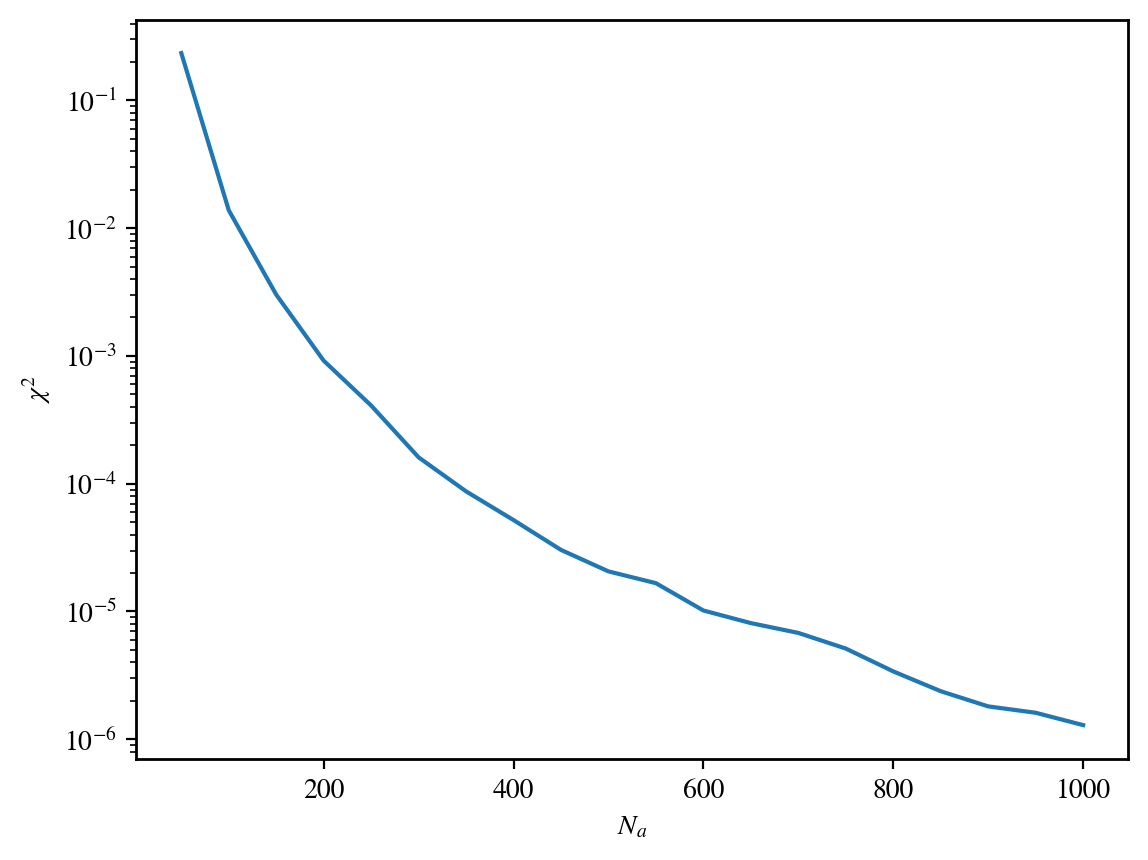

In [39]:
nlens = 10
nsrcs = 8
ndv = int(nsrcs*(nsrcs+1) + nlens*nsrcs + nlens)*ntheta

acamb = 20
nas = np.concatenate((np.linspace(50, 1000, 20),np.array([5000])))
ncl = 5000
dvs = []
for idx,na in enumerate(nas):
    print(f'loop {idx}/{len(nas)-1} start.')
    ci.initial_setup(
      adopt_limber_gg,
      adopt_limber_gs,
      adopt_RSD_gg,
      adopt_RSD_gs,
      5000,
      int(na),)
    ci.init_accuracy_boost(1.0, int(1))
    ci.init_cosmo_runmode(is_linear = False)
    ci.init_redshift_distributions_from_files(
        lens_multihisto_file=lens_file,
        lens_ntomo=int(lens_ntomo), 
        source_multihisto_file=source_file,
        source_ntomo=int(source_ntomo))
    ci.init_IA(ia_model = int(IA_model), ia_redshift_evolution = int(IA_redshift_evolution))
    
    ts, wtheta = w_theta(CAMBAccuracyBoost=3)
    ts, gammat = gamma_t(CAMBAccuracyBoost=3)
    ts, xip, xim = xi(CAMBAccuracyBoost=3)
    
    xips = []
    xims = []
    wthetas = []
    for i in range(nsrcs):
      for j in range(i,nsrcs):
        xips.append(xip[:,i,j])
        xims.append(xim[:,i,j])
    for i in range(nlens):
      wthetas.append(wtheta[:,i,i])
    xips = np.array(xips)
    xims = np.array(xims)
    wthetas = np.array(wthetas)
    
    dv = np.concatenate((
    xips.reshape(-1),
    xims.reshape(-1),
    gammat.reshape(20, -1).transpose((1,0)).reshape(-1),
    wthetas.reshape(-1)))
    dvs.append(dv)
    
import scipy

cov_raw = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/data/cov_roman')
cov = np.zeros((ndv,ndv))
for idx in range(len(cov_raw)):
    ii = int(cov_raw[idx, 0])
    jj = int(cov_raw[idx, 1])
    element = cov_raw[idx, 8] + cov_raw[idx, 9]
    cov[ii,jj] = element
    cov[jj,ii] = element
    
mask = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/data/roman_Y3.mask')[:,1].astype(bool)
invcov = scipy.linalg.inv(cov[mask,:][:,mask])

chi2s = []
for i in range(len(ncls)-1):
    delta = (dvs[i]-dvs[-1])[mask]
    chi2 = delta@invcov@delta
    chi2s.append(chi2)

plt.plot(nas[:-1], chi2s, label='Roman')
plt.yscale('log')
plt.xlabel(r'$N_a$')
plt.ylabel(r'$\chi^2$')

out = np.zeros((len(chi2s),2))
out[:, 0] = nas[:-1]
out[:, 1] = chi2s
np.savetxt('./chi2s_Na.txt', out)

In [5]:
nlens = 10
nsrcs = 8
ntheta = 20
ndv = int(nsrcs*(nsrcs+1) + nlens*nsrcs + nlens)*ntheta

na = 5000
ncl = 5000
ca = 3

ci.initial_setup(
      adopt_limber_gg,
      adopt_limber_gs,
      adopt_RSD_gg,
      adopt_RSD_gs,
      int(ncl),
      int(na),)
ci.init_accuracy_boost(1.0, int(1))
ci.init_cosmo_runmode(is_linear = False)
ci.init_redshift_distributions_from_files(
    lens_multihisto_file=lens_file,
    lens_ntomo=int(lens_ntomo), 
    source_multihisto_file=source_file,
    source_ntomo=int(source_ntomo))
ci.init_IA(ia_model = int(IA_model), ia_redshift_evolution = int(IA_redshift_evolution))

ts, wtheta = w_theta(CAMBAccuracyBoost=ca)
ts, gammat = gamma_t(CAMBAccuracyBoost=ca)
ts, xip, xim = xi(CAMBAccuracyBoost=ca)

xips = []
xims = []
wthetas = []
for i in range(nsrcs):
  for j in range(i,nsrcs):
    xips.append(xip[:,i,j])
    xims.append(xim[:,i,j])
for i in range(nlens):
  wthetas.append(wtheta[:,i,i])
xips = np.array(xips)
xims = np.array(xims)
wthetas = np.array(wthetas)

dv_final = np.concatenate((
xips.reshape(-1),
xims.reshape(-1),
gammat.reshape(20, -1).transpose((1,0)).reshape(-1),
wthetas.reshape(-1)))

/project/chihway/junzhou/cocoa_approx/Cocoa/.local/lib/python3.10/site-packages/euclidemu2/ee2_bindata.dat


In [9]:
nlens = 10
nsrcs = 8
ntheta = 20
ndv = int(nsrcs*(nsrcs+1) + nlens*nsrcs + nlens)*ntheta

na = 225*1.1
ncl = 300*1.1
ca = 1.0

ci.initial_setup(
      adopt_limber_gg,
      adopt_limber_gs,
      adopt_RSD_gg,
      adopt_RSD_gs,
      int(ncl),
      int(na),)
ci.init_accuracy_boost(1.0, int(1))
ci.init_cosmo_runmode(is_linear = False)
ci.init_redshift_distributions_from_files(
    lens_multihisto_file=lens_file,
    lens_ntomo=int(lens_ntomo), 
    source_multihisto_file=source_file,
    source_ntomo=int(source_ntomo))
ci.init_IA(ia_model = int(IA_model), ia_redshift_evolution = int(IA_redshift_evolution))

ts, wtheta = w_theta(CAMBAccuracyBoost=ca)
ts, gammat = gamma_t(CAMBAccuracyBoost=ca)
ts, xip, xim = xi(CAMBAccuracyBoost=ca)

xips = []
xims = []
wthetas = []
for i in range(nsrcs):
  for j in range(i,nsrcs):
    xips.append(xip[:,i,j])
    xims.append(xim[:,i,j])
for i in range(nlens):
  wthetas.append(wtheta[:,i,i])
xips = np.array(xips)
xims = np.array(xims)
wthetas = np.array(wthetas)

dv = np.concatenate((
xips.reshape(-1),
xims.reshape(-1),
gammat.reshape(20, -1).transpose((1,0)).reshape(-1),
wthetas.reshape(-1)))

import scipy

cov_raw = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/data/cov_roman')
cov = np.zeros((ndv,ndv))
for idx in range(len(cov_raw)):
    ii = int(cov_raw[idx, 0])
    jj = int(cov_raw[idx, 1])
    element = cov_raw[idx, 8] + cov_raw[idx, 9]
    cov[ii,jj] = element
    cov[jj,ii] = element
    
mask = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/data/roman_Y3.mask')[:,1].astype(bool)
invcov = scipy.linalg.inv(cov[mask,:][:,mask])

delta = (dv-dv_final)[mask]
chi2 = delta@invcov@delta
print(chi2)

0.0004960932965227001
